# **Business Statistics & Hypothesis Testing — Five Applied Case Studies**

### **Project Objective**

This project applies descriptive statistics and hypothesis testing to five real-world business scenarios covering lending, pricing, operational improvement, project prioritization, and customer satisfaction.

### **Statistical Techniques Used**

- Pearson Correlation
- Independent Samples t-test / Welch's t-test
- Paired t-test
- One-Way ANOVA
- Chi-Square Test of Independence
- Spearman Rank Correlation
- Descriptive Statistics

### **Tools Used**

Python | Pandas | NumPy | SciPy | Matplotlib | Jupyter Notebook

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


## **1. Data Loading and Initial Data Understanding**

Five datasets are used to address five different business problems. Initial checks include dataset dimensions, data types and missing-value identification.

In [2]:
films = pd.read_csv('films.csv')

In [3]:
loans= pd.read_csv('LoansData.csv')

In [4]:
price= pd.read_csv('Price_Quotes.csv')

In [5]:
Treatment_Facility = pd.read_csv('Treatment_Facility.csv')

In [6]:
Priority_Assessment = pd.read_csv('Priority_Assessment.csv')

In [7]:
films.head()

,_rowstate_,Movie,Gender,Marital_Status,Sinage,Parking,Clean,Overall,Age,Income,Hear_About
0,0,Ferris Buellers Day Off,Female,Married,2.0,2.0,2.0,2.0,3.0,1.0,5
1,0,Ferris Buellers Day Off,Female,Single,1.0,1.0,1.0,1.0,2.0,1.0,5
2,0,Ferris Buellers Day Off,Male,Married,2.0,4.0,3.0,2.0,4.0,1.0,5
3,0,Ferris Buellers Day Off,Female,Married,1.0,3.0,2.0,2.0,4.0,1.0,5
4,0,Ferris Buellers Day Off,Female,Married,1.0,1.0,1.0,1.0,3.0,3.0,1


In [8]:
films.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   _rowstate_      330 non-null    int64  
 1   Movie           330 non-null    object 
 2   Gender          330 non-null    object 
 3   Marital_Status  328 non-null    object 
 4   Sinage          328 non-null    float64
 5   Parking         328 non-null    float64
 6   Clean           327 non-null    float64
 7   Overall         328 non-null    float64
 8   Age             328 non-null    float64
 9   Income          314 non-null    float64
 10  Hear_About      323 non-null    object 
dtypes: float64(6), int64(1), object(4)
memory usage: 28.5+ KB


In [9]:
films.shape

(330, 11)

In [10]:
films.isnull().sum()

_rowstate_         0
Movie              0
Gender             0
Marital_Status     2
Sinage             2
Parking            2
Clean              3
Overall            2
Age                2
Income            16
Hear_About         7
dtype: int64

In [11]:
loans.head()

,Amount.Requested,Amount.Funded.By.Investors,Interest.Rate,Loan.Length,Loan.Purpose,Debt.To.Income.Ratio,State,Home.Ownership,Monthly.Income,FICO.Range,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.in.the.Last.6.Months,Employment.Length
0,20000.0,20000.0,8.90%,36 months,debt_consolidation,14.90%,SC,MORTGAGE,6541.67,735-739,14.0,14272.0,2.0,< 1 year
1,19200.0,19200.0,12.12%,36 months,debt_consolidation,28.36%,TX,MORTGAGE,4583.33,715-719,12.0,11140.0,1.0,2 years
2,35000.0,35000.0,21.98%,60 months,debt_consolidation,23.81%,CA,MORTGAGE,11500.00,690-694,14.0,21977.0,1.0,2 years
3,10000.0,9975.0,9.99%,36 months,debt_consolidation,14.30%,KS,MORTGAGE,3833.33,695-699,10.0,9346.0,0.0,5 years
4,12000.0,12000.0,11.71%,36 months,credit_card,18.78%,NJ,RENT,3195.00,695-699,11.0,14469.0,0.0,9 years


In [12]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Amount.Requested                2499 non-null   float64
 1   Amount.Funded.By.Investors      2499 non-null   float64
 2   Interest.Rate                   2498 non-null   object 
 3   Loan.Length                     2500 non-null   object 
 4   Loan.Purpose                    2500 non-null   object 
 5   Debt.To.Income.Ratio            2499 non-null   object 
 6   State                           2500 non-null   object 
 7   Home.Ownership                  2499 non-null   object 
 8   Monthly.Income                  2499 non-null   float64
 9   FICO.Range                      2498 non-null   object 
 10  Open.CREDIT.Lines               2497 non-null   float64
 11  Revolving.CREDIT.Balance        2497 non-null   float64
 12  Inquiries.in.the.Last.6.Months  24

In [13]:
loans.shape

(2500, 14)

In [14]:
loans.isnull().sum()

Amount.Requested                   1
Amount.Funded.By.Investors         1
Interest.Rate                      2
Loan.Length                        0
Loan.Purpose                       0
Debt.To.Income.Ratio               1
State                              0
Home.Ownership                     1
Monthly.Income                     1
FICO.Range                         2
Open.CREDIT.Lines                  3
Revolving.CREDIT.Balance           3
Inquiries.in.the.Last.6.Months     3
Employment.Length                 77
dtype: int64

In [15]:
price.head()

,Order_Number,Barry_Price,Mary_Price
0,1,126,114
1,2,110,118
2,3,138,114
3,4,142,111
4,5,146,129


In [16]:
price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Order_Number  12 non-null     int64
 1   Barry_Price   12 non-null     int64
 2   Mary_Price    12 non-null     int64
dtypes: int64(3)
memory usage: 420.0 bytes


In [17]:
price.shape

(12, 3)

In [18]:
price.isnull().sum()

Order_Number    0
Barry_Price     0
Mary_Price      0
dtype: int64

In [19]:
Treatment_Facility.head()

,Month,Reengineer,Employee_Turnover,VAR4,VAR5
0,1,Prior,0.0000,24.390244,42.682927
1,2,Prior,6.0606,19.354839,25.806452
2,3,Prior,12.1212,35.087719,146.198830
3,4,Prior,3.3333,18.404908,110.429448
4,5,Prior,12.9032,17.964072,23.952096


In [20]:
Treatment_Facility.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Month              20 non-null     int64  
 1   Reengineer         20 non-null     object 
 2   Employee_Turnover  20 non-null     float64
 3   VAR4               20 non-null     float64
 4   VAR5               20 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 932.0+ bytes


In [21]:
Treatment_Facility.shape

(20, 5)

In [22]:
Treatment_Facility.isnull().sum()

Month                0
Reengineer           0
Employee_Turnover    0
VAR4                 0
VAR5                 0
dtype: int64

In [23]:

Priority_Assessment.head()

,Days,Priority
0,3.3,High
1,7.9,Medium
2,0.3,High
3,0.7,Medium
4,8.6,Medium


In [24]:
Priority_Assessment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Days      642 non-null    float64
 1   Priority  642 non-null    object 
dtypes: float64(1), object(1)
memory usage: 10.2+ KB


In [25]:
Priority_Assessment.shape

(642, 2)

In [26]:
Priority_Assessment.isnull().sum()

Days        0
Priority    0
dtype: int64

# **Business Problem 1 — Lending Club Loan Analysis**

### **Objective**

To investigate whether loan amount, loan tenure and loan purpose are associated with interest rates, and whether FICO score is associated with home ownership.

## **Loan dataset cleaning**

In [27]:
loans['InterestRateNum'] =  pd.to_numeric(
        loans['Interest.Rate'].astype(str).str.replace("%",""),
        errors = 'coerce'
    )
loans['LoanLengthNum'] = pd.to_numeric(
         loans['Loan.Length'].astype(str).str.extract(r"(\d+)")[0],
         errors = 'coerce'
     )

## **1A — Loan Amount vs Interest Rate**

In [28]:
temp = loans [
['Amount.Requested','InterestRateNum']
].dropna()

r,p = stats.pearsonr(
    temp['Amount.Requested'],
    temp['InterestRateNum']
)

print('Correlation : ',r)
print('P-value:', p)

Correlation :  0.33245376620082473
P-value: 1.5803794085882206e-65


### **Business Insight**

The analysis shows a statistically significant positive relationship between loan amount and interest rate.

Contrary to the initial assumption, larger requested loan amounts tend to be associated with **higher**, rather than lower, interest rates in this datset..
.*

## **1B — Loan Length vs Interest Rate**

In [29]:
loans.groupby("Loan.Length")['InterestRateNum'].mean()

Loan.Length
36 months    12.126179
60 months    16.407464
Name: InterestRateNum, dtype: float64

In [30]:
loan36 = loans.loc[
loans['Loan.Length'] == '36 months',
'InterestRateNum'
].dropna()

loan60 = loans.loc[
loans['Loan.Length'] == '60 months',
'InterestRateNum'
].dropna()

In [31]:
stats.levene(loan36, loan60)

LeveneResult(statistic=15.996797889369777, pvalue=6.529383794820269e-05)

In [32]:
stats.ttest_ind(
    loan36,loan60,
    equal_var = False
)

TtestResult(statistic=-21.952945651707445, pvalue=3.9306165080480272e-84, df=807.5989456944106)

### **Business Insight**

Loan tenure is significantly associated with borrowing cost. The average interest rate for 60-month loans is approximately **16.41%**, compared with **12.13%** for 36-month loans.

Longer-term loans therefore carry substantially higher interest rates in this sample.

### **1C — Loan Purpose vs Interest Rate**

In [33]:
loans.groupby("Loan.Purpose")['InterestRateNum'].mean().sort_values()

Loan.Purpose
renewable_energy       9.877500
major_purchase        10.797822
educational           11.007333
car                   11.113000
home_improvement      11.594276
medical               11.649667
vacation              11.966190
wedding               12.047105
small_business        12.839195
credit_card           13.050655
other                 13.159552
house                 13.448000
debt_consolidation    13.586917
moving                13.621034
Name: InterestRateNum, dtype: float64

In [34]:
groups = [
    group['InterestRateNum'].dropna().values 
    for name , group in loans.groupby("Loan.Purpose")
]

stats.f_oneway(*groups)

F_onewayResult(statistic=7.481404351302255, pvalue=1.1686298123677374e-14)

### **Business Insight**

Interest rates differ significantly across loan purposes.

The observed average rates range from approximately **9.88% for renewable-energy loans** to **13.62% for moving-related loans**, indicating that loan purpose is associated with pricing differences.

### **1D — FICO Score vs Home Ownership**

In [35]:
table = pd.crosstab(
    loans['FICO.Range'],
    loans['Home.Ownership'])

In [36]:
chi2,p, dof, expected = stats.chi2_contingency(table)

print(chi2)
print(p)

473.05246368346025
1.2021592010244615e-35


### **Business Insight**

FICO score range and home ownership are statistically associated.

This indicates that borrowers' credit profiles differ across home-ownership categories. However, the result represents an **association and should not be interpreted as evidence that home ownership causes higher FICO scores**.

# **Business Problem 2 — Pricing Expert Consistency**

### **Objective**

To determine whether Mary and Barry provide significantly different average price quotes for the same orders.

Since both experts evaluated the same 12 orders, a **paired t-test** is used.

### **Q2 — Mary vs Barry**

In [37]:
price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Order_Number  12 non-null     int64
 1   Barry_Price   12 non-null     int64
 2   Mary_Price    12 non-null     int64
dtypes: int64(3)
memory usage: 420.0 bytes


In [38]:
price['Barry_Price'].mean()


124.33333333333333

In [39]:
price['Mary_Price'].mean()

114.75

In [40]:
price['Barry_Price'].mean() - price['Mary_Price'].mean()

9.583333333333329

In [41]:
stats.ttest_rel(
    price['Barry_Price'],
    price['Mary_Price']
)

TtestResult(statistic=2.5213765108923494, pvalue=0.02840588045242053, df=11)

### **Business Insight**

Barry's average quote is approximately **124.33**, compared with **114.75** for Mary, a difference of approximately **9.58**.

The paired t-test indicates that this difference is statistically significant. This suggests inconsistency between pricing experts and supports reviewing or standardizing the quotation process.

# **Business Problem 3 — Reengineering Effectiveness**

### **Objective**

To evaluate whether the reengineering initiative improved employee turnover and resident behavioral outcomes by comparing the Prior and Post periods.

### **Q3 — Reengineering**

In [42]:
reeng = Treatment_Facility.rename(
    columns = {'VAR4':'TRFF','VAR5':'CI' }
)

In [43]:
reeng.groupby("Reengineer")[['Employee_Turnover','TRFF','CI']].mean()

,Employee_Turnover,TRFF,CI
Reengineer,,,
Post,18.689129,9.232042,23.349719
Prior,11.735692,20.540335,53.887906


In [44]:
prior = reeng[
reeng['Reengineer'] == 'Prior'
]['Employee_Turnover']

post = reeng[
reeng['Reengineer'] == 'Post'
]['Employee_Turnover']

stats.ttest_ind(
    prior,
    post,
    equal_var = False
)

TtestResult(statistic=-1.5653912078421088, pvalue=0.15207128913702453, df=8.9627915380156)

In [45]:
prior = reeng[
reeng['Reengineer'] == 'Prior'
]['TRFF']

post = reeng[
reeng['Reengineer'] == 'Post'
]['TRFF']

stats.ttest_ind(
    prior,
    post,
    equal_var = False
)

TtestResult(statistic=3.690382530309883, pvalue=0.0022744273676772084, df=14.591966534846083)

In [46]:
prior = reeng[
reeng['Reengineer'] == 'Prior'
]['CI']

post = reeng[
reeng['Reengineer'] == 'Post'
]['CI']

stats.ttest_ind(
    prior,
    post,
    equal_var = False
)

TtestResult(statistic=2.209006531430452, pvalue=0.045565519570193204, df=13.113544427198562)

### **Business Insight**

The reengineering initiative produced mixed results.

- **TRFF decreased significantly**, indicating improvement.
- **Critical Incident rates decreased significantly**, indicating improved resident behavioral outcomes.
- **Employee turnover did not improve significantly** and was actually higher during the post-reengineering period.

Overall, the initiative appears effective in improving resident-related outcomes, but additional action is required to address employee retention.

# **Business Problem 4 — Job Priority System Effectiveness**

### **Objective**

To determine whether the prioritization system is working as intended, where High-priority jobs should be completed faster than Medium-priority jobs and Medium-priority jobs faster than Low-priority jobs.

### **Q4 — Priority Assessment**

In [47]:
Priority_Assessment.groupby("Priority")["Days"].mean()

Priority
High      3.023620
Low       4.228358
Medium    2.500000
Name: Days, dtype: float64

In [48]:
Priority_Assessment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 642 entries, 0 to 641
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Days      642 non-null    float64
 1   Priority  642 non-null    object 
dtypes: float64(1), object(1)
memory usage: 10.2+ KB


In [49]:
high = Priority_Assessment[
Priority_Assessment['Priority'] == 'High'
]['Days']

medium = Priority_Assessment[
Priority_Assessment['Priority'] == 'Medium'
]['Days']

low = Priority_Assessment[
Priority_Assessment['Priority'] == 'Low'
]['Days']

stats.f_oneway(
    high, medium, low
)

F_onewayResult(statistic=1.812311010076072, pvalue=0.16411459461716182)

### **Business Insight**

Average completion times are approximately:

- **High Priority:** 3.02 days
- **Medium Priority:** 2.50 days
- **Low Priority:** 4.23 days

The ANOVA result does not provide sufficient evidence of a statistically significant difference in average completion time across the three priority groups.

In addition, the observed ordering is:

**Medium < High < Low**

rather than the intended:

**High < Medium < Low**

Therefore, the prioritization system is **not clearly operating as intended**, and management should review how job priorities are assigned and executed.

# **Business Problem 5 — Film on the Rocks Customer Analysis**

### **Objective**

To evaluate overall customer satisfaction, identify factors associated with satisfaction, understand the demographic profile of patrons, and determine the most effective media channels for promotion.

In [50]:
films.drop(
    columns='_rowstate_',
    inplace = True
)

In [51]:
films['Gender_clean'] = films['Gender'].replace(
    {'1':'Male',
    '2':'Female',
     1: 'Male',
     2:'Female',
     'Male':'Male',
     'Female':'Female'
    }
)

In [52]:
films['Marital_Status_clean'] = films['Marital_Status'].replace(
    {'1':'Married',
    '2':'Single',
     1: 'Married',
     2:'Single',
     'Married':'Married',
     'Single':'Single',
     'Slngle' : 'Single'
    }
)

### **5A — Overall Satisfaction**

In [53]:
films["Overall"].mean()

1.6189024390243902

In [54]:
valid = films['Overall'].dropna()

(valid <= 2).mean() * 100

94.8170731707317

### **Business Insight**

Overall customer satisfaction is very high.

The average overall satisfaction score is approximately **1.62**, where 1 represents Excellent and 2 represents Good. Approximately **94.82%** of valid respondents rated their overall experience as either Excellent or Good.

This indicates a strong overall customer experience.

## **5B — What Factors Are Linked to Satisfaction?**

In [55]:
for col in ["Sinage", "Parking", "Clean"]:

    temp = films[
        [col, "Overall"]
    ].dropna()

    r, p = stats.spearmanr(
        temp[col],
        temp["Overall"]
    )

    print(col, r, p)

Sinage 0.45578905252824015 3.529022031216999e-18
Parking 0.5388462406948585 5.071904161049538e-26
Clean 0.4323740223095961 2.5032055899603427e-16


### **Business Insight**

Signage, parking and cleanliness are all significantly associated with overall customer satisfaction.

Among these factors, **Parking has the strongest association with overall satisfaction (ρ ≈ 0.539)**.

Therefore, parking should receive particular attention when management considers improvements to the customer experience.


## **5C — Demographic Profile**

In [56]:
print("Gender clean:", films["Gender_clean"].unique())
print("Marital Status clean:", films["Marital_Status_clean"].unique())
print("Age:", films["Age"].unique())
print("Income:", films["Income"].unique())

Gender clean: ['Female' 'Male']
Marital Status clean: ['Married' 'Single' nan]
Age: [ 3.  2.  4.  1. nan]
Income: [ 1.  3. nan  2.]


In [57]:
films["Marital_Status_clean"].isnull().sum()

2

In [58]:
films["Marital_Status_clean"].value_counts(dropna=False)

Marital_Status_clean
Single     228
Married    100
NaN          2
Name: count, dtype: int64

In [59]:
films["Marital_Status_clean"].value_counts(normalize=True).mul(100).round(2)

Marital_Status_clean
Single     69.51
Married    30.49
Name: proportion, dtype: float64

In [60]:
age_map = {
    1: "1-12",
    2: "13-30",
    3: "31-60",
    4: "60+"
}

films["Age_Group"] = films["Age"].map(age_map)

In [61]:
print("Original Age:", films["Age"].unique())
print("Clean Age:", films["Age_Group"].unique())

Original Age: [ 3.  2.  4.  1. nan]
Clean Age: ['31-60' '13-30' '60+' '1-12' nan]


In [62]:
income_map = {
    1: "< $50,000",
    2: "$50,000-$100,000",
    3: "$100,000+"
}

films["Income_Group"] = films["Income"].map(income_map)

In [63]:
print("Original Income:", films["Income"].unique())
print("Clean Income:", films["Income_Group"].unique())

Original Income: [ 1.  3. nan  2.]
Clean Income: ['< $50,000' '$100,000+' nan '$50,000-$100,000']


In [64]:
print("Missing Values")

print("Gender:",
      films["Gender_clean"].isnull().sum())

print("Marital Status:",
      films["Marital_Status_clean"].isnull().sum())

print("Age:",
      films["Age_Group"].isnull().sum())

print("Income:",
      films["Income_Group"].isnull().sum())

Missing Values
Gender: 0
Marital Status: 2
Age: 2
Income: 16


In [65]:
films["Gender_clean"].value_counts(
    normalize=True
).mul(100).round(2)

Gender_clean
Female    64.55
Male      35.45
Name: proportion, dtype: float64

In [66]:
films["Marital_Status_clean"].value_counts(
    normalize=True
).mul(100).round(2)

Marital_Status_clean
Single     69.51
Married    30.49
Name: proportion, dtype: float64

In [67]:
films["Age_Group"].value_counts(
    normalize=True
).mul(100).round(2)

Age_Group
13-30    53.35
31-60    35.67
1-12      7.93
60+       3.05
Name: proportion, dtype: float64

In [68]:
films["Income_Group"].value_counts(
    normalize=True
).mul(100).round(2)

Income_Group
< $50,000           45.22
$100,000+           28.66
$50,000-$100,000    26.11
Name: proportion, dtype: float64

### **Business Insight**

The survey audience is predominantly:

- **Female:** approximately 64.55%
- **Single:** approximately 69.51% of valid marital-status responses
- **Age 13–30:** the largest age group
- **Income below $50,000:** approximately 45.22% of valid income responses

The audience therefore skews toward younger, single female patrons, with the largest income segment below $50,000.

This demographic profile can help promoters refine audience targeting and sponsorship strategies.

## **5D — Which Media Outlet?**

In [69]:
films.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Movie                 330 non-null    object 
 1   Gender                330 non-null    object 
 2   Marital_Status        328 non-null    object 
 3   Sinage                328 non-null    float64
 4   Parking               328 non-null    float64
 5   Clean                 327 non-null    float64
 6   Overall               328 non-null    float64
 7   Age                   328 non-null    float64
 8   Income                314 non-null    float64
 9   Hear_About            323 non-null    object 
 10  Gender_clean          330 non-null    object 
 11  Marital_Status_clean  328 non-null    object 
 12  Age_Group             328 non-null    object 
 13  Income_Group          314 non-null    object 
dtypes: float64(6), object(8)
memory usage: 36.2+ KB


In [70]:
films["Hear_About"].unique()

array(['5', '1', '4', '2', '3', '4,5', '2,5', '1,5', nan, '3,4', '5,4',
       '3,5'], dtype=object)

In [71]:
from collections import Counter

media_count = Counter()

for value in films["Hear_About"].dropna().astype(str):
    for item in value.split(","):
        media_count[item.strip()] += 1

media_count

Counter({'5': 232, '4': 45, '1': 23, '3': 17, '2': 14})

In [72]:
media_map = {
    "1": "Television",
    "2": "Newspaper",
    "3": "Radio",
    "4": "Website",
    "5": "Word of Mouth"
}

media_result = pd.Series({
    media_map[code]: count
    for code, count in media_count.items()
}).sort_values(ascending=False)

media_result

Word of Mouth    232
Website           45
Television        23
Radio             17
Newspaper         14
dtype: int64

In [73]:
media_percentage = (
    media_result / len(films) * 100
).round(2)

media_percentage

Word of Mouth    70.30
Website          13.64
Television        6.97
Radio             5.15
Newspaper         4.24
dtype: float64

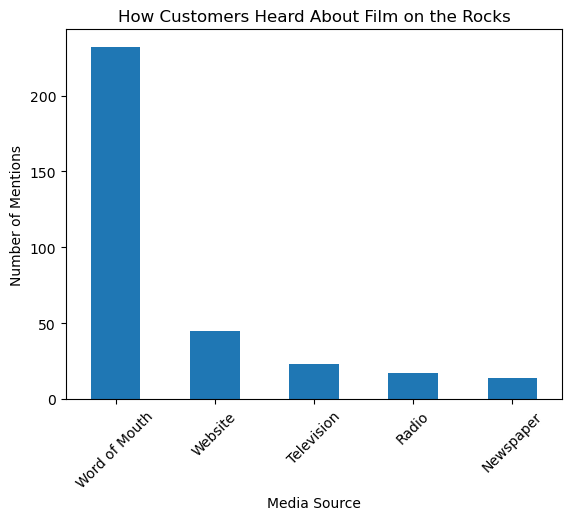

In [74]:
media_result.plot(
    kind="bar",
    title="How Customers Heard About Film on the Rocks"
)

plt.xlabel("Media Source")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45)
plt.show()

### **Business Insight**

**Word of Mouth is the dominant awareness channel**, mentioned by approximately 70.30% of respondents.

Among controllable advertising channels, **Website has the highest reach at approximately 13.64%**.

The promoters should therefore prioritize digital/website marketing while also encouraging referral and word-of-mouth activity.

# **Executive Summary**

This project applied statistical analysis to five different business scenarios to convert raw data into actionable business insights.

### **Key Findings**

**Lending Club:** Loan amount, loan tenure and loan purpose are significantly associated with interest rates. Contrary to the original assumption, larger requested loans tend to be associated with higher interest rates. FICO range is also associated with home ownership.

**Pricing Process:** Mary and Barry provide significantly different average quotes for the same orders, suggesting that greater pricing standardization may be required.

**Reengineering Program:** The initiative significantly reduced temporary removals and critical incidents, but did not significantly improve employee turnover.

**Priority Management:** The job-priority system does not demonstrate the intended High → Medium → Low completion-time pattern and should be reviewed.

**Film on the Rocks:** Customer satisfaction is very high. Parking has the strongest measured association with overall satisfaction. The audience is predominantly younger, female and single, while Word of Mouth is the dominant awareness source and Website is the strongest controllable advertising channel.

### **Overall Learning**

The project demonstrates how descriptive statistics and hypothesis testing can be used to evaluate business assumptions, identify meaningful relationships, compare groups and translate statistical results into practical business recommendations.